# Notebook For Analysis

# Setup

In [1]:
!echo $HOSTNAME
!python --version
!nvidia-smi

c026
Python 3.12.5
/bin/bash: line 1: nvidia-smi: command not found


In [2]:
# General Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
from fancy_einsum import einsum
import os
import sys
import tqdm.auto as tqdm
import random
from pathlib import Path
import plotly.express as px
import copy

from typing import List, Union, Optional
from functools import partial
import itertools
from IPython.display import HTML

# CSV Use Libraries
import pandas as pd

# Function Imports
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Unused
# from torch.utils.data import DataLoader
# from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer
# import dataclasses
# import datasets
# import ast
# from transformers import get_cosine_schedule_with_warmup #Used for lr?
# from torch.nn.utils import clip_grad_norm_

In [4]:
from config import *

# Shared helpers live in Transformer.py (the training script). Importing them does
# NOT trigger training — that is guarded by `if __name__ == "__main__"`.
from Transformer import (
    setup_device, build_model, load_and_split_data, load_checkpoint_into,
    descent_loss_fn, descent_accuracy_fn, descent_sequence_accuracy,
    create_attention_mask, register_pad_mask_hook,
)

## Define Graphing Functs

In [5]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"
print(f"Using renderer: {pio.renderers.default}")

Using renderer: notebook_connected


In [6]:
import plotly.io as pio

# Now you can safely style your plot layouts
pio.templates['plotly'].layout.xaxis.title.font.size = 20
pio.templates['plotly'].layout.yaxis.title.font.size = 20
pio.templates['plotly'].layout.title.font.size = 30

In [7]:
import sys
import transformer_lens
import transformer_lens.utilities as utils
from transformer_lens import HookedTransformer

# Unpickling shim: checkpoints pickled by other transformer_lens versions may reference
# the config class through the old top-level module path. Alias it if this version
# provides the new path; skip silently if the layout changes again.
try:
    import transformer_lens.config.hooked_transformer_config as htc
    sys.modules.setdefault('transformer_lens.HookedTransformerConfig', htc)
except ImportError:
    pass

In [8]:
# Unused plotting functions in favor of Neel Plotly

# def imshow(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
#     px.imshow(utils.to_numpy(tensor), color_continuous_midpoint=0.0, color_continuous_scale="RdBu", labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

# def line(tensor, renderer=None, xaxis="", yaxis="", **kwargs):
#     px.line(utils.to_numpy(tensor), labels={"x":xaxis, "y":yaxis}, **kwargs).show(renderer)

# def scatter(x, y, xaxis="", yaxis="", caxis="", renderer=None, **kwargs):
#     x = utils.to_numpy(x)
#     y = utils.to_numpy(y)
#     px.scatter(y=y, x=x, labels={"x":xaxis, "y":yaxis, "color":caxis}, **kwargs).show(renderer)

## Set Paths and GPU Devices

In [9]:
import os
from pathlib import Path
from config import * # Safely loads DATA_PATH and PTH_LOCATION now!

# Create the directory if it doesn't exist yet
os.makedirs(Path(PTH_LOCATION).parent, exist_ok=True)
print(f"Data Dir:  {DATA_PATH}")
print(f"Model PTH: {PTH_LOCATION}")

Data Dir:  /home/katyala/CoxeterArtinProject/transformer/2026/PranavCode
Model PTH: /home/katyala/CoxeterArtinProject/transformer/2026/PranavCode/workspace/_scratch/model.pth


In [10]:
from Transformer import setup_device

# Now call the function to initialize your devices
device, device1 = setup_device()
print(f"Active hardware devices: {device}, {device1}")

CUDA available: False
Device count: 0
Device Name: cpu
Active hardware devices: cpu, None


## Define Model and Optimizer Params

In [11]:
import torch
from Transformer import build_model, load_checkpoint_into

torch.manual_seed(seed=DATA_SEED)
torch.cuda.manual_seed_all(DATA_SEED)

# 1. Intercept PyTorch's load function to force CPU mapping everywhere automatically
orig_load = torch.load
torch.load = lambda *args, **kwargs: orig_load(*args, **{**kwargs, 'map_location': torch.device('cpu')})

try:
    # 2. Load the config array
    cached_data = torch.load(PTH_LOCATION, weights_only=False)
    cfg = cached_data["config"]

    # 3. Force TransformerLens to build modules on CPU
    cfg.device = "cpu"

    # 4. Reconstruct and pull the history out
    model, optimizer, scheduler = build_model(cfg)
    _, history = load_checkpoint_into(model, optimizer, scheduler)

finally:
    # 5. Restore torch.load to normal so we don't break anything else later
    torch.load = orig_load

# 6. Unpack your training curves
model_checkpoints = history["checkpoints"]
checkpoint_epochs = history["checkpoint_epochs"]
train_losses      = history["train_losses"]
test_losses       = history["test_losses"]
train_accuracies  = history["train_accuracies"]
test_accuracies   = history["test_accuracies"]
train_bit_accuracies = history["train_bit_accuracies"]
test_bit_accuracies  = history["test_bit_accuracies"]

print("Model weights and training history unpacked successfully on CPU!")

Model weights and training history unpacked successfully on CPU!


## Misc Setup
Loss/accuracy/masking functions are imported from `Transformer.py` at the top.

In [13]:
torch.cuda.empty_cache()
clsDex = SEQUENCE_LENGTH - 1 # index of classification token, kept for attention pattern analysis

## Initialize Datasets

In [14]:
from Transformer import load_and_split_data

# Use device1 (your CPU/GPU target) to load, split, and shuffle the data
data = load_and_split_data(device1)

train_tokens,  test_tokens  = data["train_tokens"],  data["test_tokens"]
train_targets, test_targets = data["train_targets"], data["test_targets"]
train_mask,    test_mask    = data["train_mask"],    data["test_mask"]
train_attention_mask = data["train_attention_mask"]
test_attention_mask  = data["test_attention_mask"]

print(f"Data split successfully! Training shape: {train_tokens.shape}")

Loaded dataset: tokens (2257, 54) | targets (2257, 54, 3)
Train size: 902 | Test size: 1355 | Seq Len: 54
Data split successfully! Training shape: torch.Size([902, 54])


# Graph Results

In [35]:
from neel_plotly.plot import line_or_scatter, line as neel_line

In [36]:
import numpy as np
import plotly.express as px

print(CHECKPOINT_STEP)
skipBy = 1

# A clean, native Plotly replacement for line_or_scatter
def line_or_scatter(data_list, x, xaxis, yaxis, title, line_labels, log_y=True, **kwargs):
    import pandas as pd
    
    # Structure the data for Plotly Express
    df_dict = {xaxis: np.tile(x, len(data_list))}
    values = []
    labels = []
    
    for dataset, label in zip(data_list, line_labels):
        # Convert PyTorch tensors to CPU numpy arrays if necessary
        clean_data = [d.item() if hasattr(d, 'item') else d for d in dataset]
        values.extend(clean_data)
        labels.extend([label] * len(clean_data))
        
    df_dict[yaxis] = values
    df_dict["Legend"] = labels
    df = pd.DataFrame(df_dict)
    
    # Notice we set log_y=False for accuracies, but keep it configurable
    fig = px.line(df, x=xaxis, y=yaxis, color="Legend", title=title, log_y=log_y)
    return fig

def createGraph(yTrain, yTest, yName, title, log_y=True):
    fig = line_or_scatter(
        [yTrain[::skipBy], yTest[::skipBy]],
        x=np.arange(0, len(yTrain), skipBy),
        xaxis="Epoch",
        yaxis=yName,
        log_y=log_y,
        title=title,
        line_labels=['train', 'test']
    )
    return fig

# 1. Generate the interactive plots
# Note: It's usually better to keep Accuracy curves on a linear scale (log_y=False) 
# so you can clearly see them climb towards 1.0 (100%).
fig1 = createGraph(train_losses, test_losses, "Loss", "Loss Curve for Word Problem", log_y=True)
fig2 = createGraph(train_accuracies, test_accuracies, "Accuracy", "Accuracy Curve for Word Problem", log_y=False)
fig3 = createGraph(train_bit_accuracies, test_bit_accuracies, "Per Bit Accuracy", "Per Bit Accuracy Curve for Word Problem", log_y=False)

# 2. ZOOM IN / STRETCH THE X-AXIS HERE
# We set the x-axis range from Epoch 0 to 30 to stretch out the initial learning phase.
# (Change 30 to 50 if you want to see a slightly wider window!)
for fig in [fig1, fig2, fig3]:
    fig.update_xaxes(range=[0, 30])

# Render them inside your notebook browser
fig1.show()
fig2.show()
fig3.show()

# Save them out cleanly as HTML files with the zoomed view preserved
fig1.write_html("1. loss_curve.html")
fig2.write_html("2. accuracy_curve.html")
fig3.write_html("3. bit_accuracy.html")

100


# Analysing the Model

Helpful Memory Probing Functions:

- nvidia-smi
- torch.cuda.empty_cache()
- torch.set_grad_enabled(mode=False)
- gc.collect()
- print(torch.cuda.memory_summary())
- torch profiler also (saved image on Aug 03, 2025 ~6pm)

### Helper Functions
- logit return function
- prediction function

In [17]:
import gc

def getLogits(model: HookedTransformer, tokens, getCache: bool = False):
    """
    Applies the padding mask and runs a forward pass.
    Returns detached logits (and optionally the activation cache).
    """
    with torch.inference_mode():
        model.reset_hooks()
        mask = create_attention_mask(tokens).to(device1)
        register_pad_mask_hook(model, mask)
        if getCache:
            original_logits_og, cache = model.run_with_cache(tokens)
        else:
            original_logits_og = model(tokens)
    original_logits = original_logits_og.detach().clone()
    del original_logits_og, mask
    torch.cuda.empty_cache()
    if getCache:
        return original_logits, cache
    else:
        return original_logits

def getPredictions(model: HookedTransformer, tokens, targets, mask):
    """
    Per-sequence descent accuracy: fraction of prefixes whose descent set is
    exactly correct. Shape: (batch_size,)
    """
    logits  = getLogits(model, tokens, getCache=False)
    seq_acc = descent_sequence_accuracy(logits, targets, mask)
    del logits
    return seq_acc

def imshow(tensor, renderer=None, xaxis="", yaxis="", xlabels=None, ylabels=None, aspect="auto", **kwargs):
    fig = px.imshow(
        utils.to_numpy(tensor),
        color_continuous_midpoint=0.0,
        color_continuous_scale="RdBu",
        labels={"x": xaxis, "y": yaxis},
        aspect=aspect,
        **kwargs
    )
    if xlabels is not None:
        fig.update_xaxes(tickmode='array', tickvals=list(range(len(xlabels))), ticktext=xlabels)
    if ylabels is not None:
        fig.update_yaxes(tickmode='array', tickvals=list(range(len(ylabels))), ticktext=ylabels)
    fig.update_yaxes(scaleanchor=None)
    fig.show(renderer)
    return fig

def cleanup():
    gc.collect()
    torch.cuda.empty_cache()

## Quick Analysis + Memory Cleanup

In [18]:
import torch
import gc
from Transformer import create_attention_mask, register_pad_mask_hook

# 1. Pull the logits and activation cache from the model safely
original_logits, cache = getLogits(model, train_tokens, getCache=True)

print(f"Logits successfully extracted! Shape: {original_logits.shape}")
print("Activation cache successfully populated.")

# 2. Freeze gradients and clean up memory structures
torch.set_grad_enabled(False)
gc.collect()
torch.cuda.empty_cache()

Logits successfully extracted! Shape: torch.Size([902, 54, 3])
Activation cache successfully populated.


In [19]:
from Transformer import create_attention_mask, register_pad_mask_hook

# Now you can safely call getLogits, and it will have access to its masking functions!
original_logits, cache = getLogits(model, train_tokens, getCache=True)

print(f"Logits successfully extracted! Shape: {original_logits.shape}")
print("Activation cache successfully populated.")

Logits successfully extracted! Shape: torch.Size([902, 54, 3])
Activation cache successfully populated.


Get key weight matrices:

In [20]:
W_E = model.embed.W_E[:-1]
print("W_E", W_E.shape)
W_neur = W_E @ model.blocks[0].attn.W_V @ model.blocks[0].attn.W_O @ model.blocks[0].mlp.W_in
print("W_neur", W_neur.shape)
W_logit = model.blocks[0].mlp.W_out @ model.unembed.W_U
print("W_logit", W_logit.shape)

W_E torch.Size([3, 256])
W_neur torch.Size([4, 3, 1024])
W_logit torch.Size([1024, 3])


In [21]:
from Transformer import descent_loss_fn

# Calculate the initial model loss cleanly
original_loss = descent_loss_fn(original_logits, train_targets, train_mask).item()
print("Original Loss:", original_loss)

Original Loss: 0.6975977420806885


### Looking at Activations

Get all shapes:

In [22]:
for param_name, param in cache.items():
    print(param_name, param.shape)

hook_embed torch.Size([902, 54, 256])
hook_pos_embed torch.Size([902, 54, 256])
blocks.0.hook_resid_pre torch.Size([902, 54, 256])
blocks.0.attn.hook_q torch.Size([902, 54, 4, 64])
blocks.0.attn.hook_k torch.Size([902, 54, 4, 64])
blocks.0.attn.hook_v torch.Size([902, 54, 4, 64])
blocks.0.attn.hook_attn_scores torch.Size([902, 4, 54, 54])
blocks.0.attn.hook_pattern torch.Size([902, 4, 54, 54])
blocks.0.attn.hook_z torch.Size([902, 54, 4, 64])
blocks.0.hook_attn_out torch.Size([902, 54, 256])
blocks.0.hook_resid_mid torch.Size([902, 54, 256])
blocks.0.mlp.hook_pre torch.Size([902, 54, 1024])
blocks.0.mlp.hook_post torch.Size([902, 54, 1024])
blocks.0.hook_mlp_out torch.Size([902, 54, 256])
blocks.0.hook_resid_post torch.Size([902, 54, 256])
blocks.1.hook_resid_pre torch.Size([902, 54, 256])
blocks.1.attn.hook_q torch.Size([902, 54, 4, 64])
blocks.1.attn.hook_k torch.Size([902, 54, 4, 64])
blocks.1.attn.hook_v torch.Size([902, 54, 4, 64])
blocks.1.attn.hook_attn_scores torch.Size([902, 4

In [23]:
print(model)

# debug: prints the first 4 input train data values
print(train_tokens[:4])

# Embedding matrix W_E: [d_vocab, d_model] = (4, 256) — 3 generators + the padding token.
# The last row is the padding token's embedding; [:-1] drops it.
# print(model.embed.W_E.shape)
# print(model.embed.W_E)
# print(model.embed.W_E[:-1])

# Embedding a batch of tokens: [batch, seq_len] -> [batch, seq_len, d_model]
# print(train_tokens.shape)
# print(model.embed(train_tokens).shape)

HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint(name='hook_embed')
  (pos_embed): PosEmbed()
  (hook_pos_embed): HookPoint(name='hook_pos_embed')
  (blocks): ModuleList(
    (0): TransformerBlock(
      (ln1): Identity()
      (ln2): Identity()
      (attn): Attention(
        (hook_k): HookPoint(name='blocks.0.attn.hook_k')
        (hook_q): HookPoint(name='blocks.0.attn.hook_q')
        (hook_v): HookPoint(name='blocks.0.attn.hook_v')
        (hook_z): HookPoint(name='blocks.0.attn.hook_z')
        (hook_attn_scores): HookPoint(name='blocks.0.attn.hook_attn_scores', 1 fwd)
        (hook_pattern): HookPoint(name='blocks.0.attn.hook_pattern')
        (hook_result): HookPoint(name='blocks.0.attn.hook_result')
      )
      (mlp): MLP(
        (hook_pre): HookPoint(name='blocks.0.mlp.hook_pre')
        (hook_post): HookPoint(name='blocks.0.mlp.hook_post')
      )
      (hook_attn_in): HookPoint(name='blocks.0.hook_attn_in')
      (hook_q_input): HookPoint(name='blocks.0.h

## Attention Heads (average)

### Average attention over all words for each head
Note: all train data input words used and averaged out for these graphs
- x: letters (keys attended to)
- y: letters (query giving attention to x axis)

In [24]:
n_heads = model.cfg.n_heads

with torch.inference_mode():
    for layer in range(model.cfg.n_layers):
        head_sums   = None   # reset per layer
        num_samples = 0

        for wordIndex in range(len(train_tokens)):
            # Grab attention pattern: [n_heads, seq_len, seq_len]
            attn_patterns = cache["pattern", layer][wordIndex]

            if head_sums is None:
                head_sums = torch.zeros_like(attn_patterns)

            head_sums   += attn_patterns
            num_samples += 1

        # Average attention
        avg_attn = head_sums / num_samples
        
        # Dynamically create labels based on the ACTUAL size of the matrix
        matrix_size = avg_attn.shape[-1]
        str_tokens = [str(i) for i in range(matrix_size)]

        for head in range(n_heads):
            imshow(
                avg_attn[head].detach().cpu(),
                x=str_tokens,
                y=str_tokens,
                xaxis="Key (Attended To)",
                yaxis="Query (Paying Attention)",
                title=f"Layer {layer} Head {head} — Average Attention Across Dataset",
                aspect=None,
            )

### Average Attention Pattern over Attention Heads

In [25]:
# Dynamically set clsDex to the very last token index of your sequence
clsDex = train_tokens.shape[1] - 1  # This will automatically equal 14

for layer in range(model.cfg.n_layers):
    # Grab the attention pattern and slice safely
    attention = cache["pattern", layer].mean(dim=0)[:, clsDex, :]
    
    imshow(
        attention,
        title=f"Average Attention Paid | for token {clsDex} | per head | layer {layer}",
        xaxis="Source",
        yaxis="Head",
        x=[str(i) for i in range(train_tokens.shape[1])],
        ylabels=[f"{i}" for i in range(attention.shape[0])]
    )

## Attention Heads (word: X)

In [26]:
import torch
from Transformer import descent_sequence_accuracy

# Look at a specific word in the dataset by its (shuffled) index
wordIndex = 100

# Evaluate the model on a single word
wordTensor  = train_tokens[wordIndex]
wordTokens  = wordTensor.unsqueeze(0)                  # add batch dimension
wordTargets = train_targets[wordIndex].unsqueeze(0)
wordMask    = train_mask[wordIndex].unsqueeze(0)
seq_acc = getPredictions(model, wordTokens, wordTargets, wordMask)

logits = getLogits(model, wordTokens, getCache=False)
probs = torch.sigmoid(logits)
preds = (probs > 0.5).int()

print(f"Word:    {wordTensor.tolist()}")

for t in range(wordTokens.shape[1]):
    true_labels = wordTargets[0, t].int().tolist()
    pred_labels = preds[0, t].tolist()

    print(f"{t:02d}  True: {true_labels}   Pred: {pred_labels}   Correct:{true_labels == pred_labels}")

print(f"Seq Acc: {seq_acc.item():.4f}  (fraction of prefixes with an exactly-correct descent set)")

Word:    [3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 1, 3, 1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
00  True: [0, 0, 0]   Pred: [1, 0, 0]   Correct:False
01  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
02  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
03  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
04  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
05  True: [0, 0, 0]   Pred: [0, 0, 0]   Correct:True
06  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
07  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
08  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
09  True: [0, 0, 0]   Pred: [1, 1, 0]   Correct:False
10  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
11  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
12  True: [0, 0, 0]   Pred: [0, 0, 0]   Correct:True
13  True: [0, 0, 0]   Pred: [0, 1, 0]   Correct:False
14  True: [0, 0, 0]   Pred: [0, 0, 0]   Correct:True
15  True: [0, 0, 0]  

In [27]:
# Look at a specific word in the dataset by its (shuffled) index
testIndex = 0

# Evaluate the model on a single word
wordTensor  = test_tokens[testIndex]
wordTokens  = wordTensor.unsqueeze(0)                  # add batch dimension
wordTargets = test_targets[testIndex].unsqueeze(0)
wordMask    = test_mask[testIndex].unsqueeze(0)
seq_acc = getPredictions(model, wordTokens, wordTargets, wordMask)

logits = getLogits(model, wordTokens, getCache=False)
probs = torch.sigmoid(logits)
preds = (probs > 0.5).int()

# Print decoded word representation (translating tokens 1, 2, 3 to a, b, c)
print("Word:    ", end="")
for i in range(len(wordTensor)):
    print("a", end="") if wordTensor[i] == 1 else None
    print("b", end="") if wordTensor[i] == 2 else None
    print("c", end="") if wordTensor[i] == 3 else None
print()

# Print evaluation loop
for t in range(wordTokens.shape[1]):
    # Skip printing if this step was masked out (i.e., it was a -1 placeholder or padding)
    if wordMask[0, t] == 0:
        continue

    true_labels = wordTargets[0, t].int().tolist()
    pred_labels = preds[0, t].tolist()

    print(f"{t:02d}  True: {true_labels}   Pred: {pred_labels}   Correct:{true_labels == pred_labels}")

print(f"Seq Acc: {seq_acc.item():.4f}  (fraction of evaluated steps with an exactly-correct descent set)")

Word:    acabacba
07  True: [1, 0, 1]   Pred: [0, 1, 0]   Correct:False
Seq Acc: 0.0000  (fraction of evaluated steps with an exactly-correct descent set)


### Attention patterns per each head on ONE word
- prints 4 graphs

### Attention Pattern for wordIndex over attention Heads

In [28]:
import plotly.express as px

# Link to the active sequence tensor evaluated in the cell above
chosenWord = wordTokens 
clsDex = 0 # Maps attention looking back from your target token index

# 1. Standardize string labels for your horizontal sequence x-axis
token_strs = [str(x) for x in chosenWord.squeeze(0).tolist()]

# 2. Iterate through transformer layers and render the heatmaps
for layer in range(model.cfg.n_layers):
    # Pulling layer pattern slice: shape is usually (heads, dest_seq, src_seq)
    # We slice at [0] for the batch item
    attention_slice = cache["pattern", layer][0] 
    
    # Let's take the attention pattern looking at all positions, 
    # converting the PyTorch tensor to a CPU numpy array for Plotly
    matrix_to_plot = attention_slice.cpu().numpy()
    
    # If the tensor has 3 dimensions (heads, dest_pos, src_pos), let's plot the average 
    # attention across heads, or look at a specific head layout.
    # To see the full matrix across all heads, we can average them or pick a slice:
    if len(matrix_to_plot.shape) == 3:
        # Averaging across attention heads for a clean overview per layer
        matrix_to_plot = matrix_to_plot.mean(axis=0)

    fig = px.imshow(
        matrix_to_plot,
        title=f"Attention Pattern Overview (Word {wordIndex}) - Layer {layer}",
        labels=dict(x="Source Tokens", y="Destination Tokens", color="Attention Weight"),
        x=token_strs,
        y=[f"Pos {i}" for i in range(matrix_to_plot.shape[0])],
        color_continuous_scale="Viridis"
    )
    
    fig.update_layout(title_font_size=20)
    fig.show()

print("Sequence Token Positions:", [str(i) for i in range(train_tokens.shape[1])])
print("Token Mapping Strings:", token_strs)

Sequence Token Positions: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53']
Token Mapping Strings: ['1', '3', '1', '2', '1', '3', '2', '1', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0', '0']


## Positional Encoding
Rotary positional embeddings (`positional_embedding_type="rotary"`): position is **not** a learned vector added to the residual stream (there is no `model.pos_embed`). Instead, fixed sine/cosine rotations are applied to the query and key vectors inside every attention layer, so attention scores depend on the **relative** offset between positions. This is what lets the model learn one position-independent rule and apply it at every prefix (see REPORT.md, exp01).
- **Heatmaps** of the fixed rotary basis `rotary_sin` / `rotary_cos` (position x rotary dimension).
- **Cosine-similarity** matrix between per-position rotary vectors — banded/Toeplitz structure that depends only on the position *difference*.

## Misclassification Graphs
- Counting how many times the model predicts an incorrect descent set at each token index (position). With causal masking each index is an independent prediction over its prefix.

### Train Misclassification Graphs:

In [37]:
from collections import defaultdict
import matplotlib.pyplot as plt


def position_error_counts(model, tokens, targets, mask):
    """
    Per-token-index misclassification counts.

    With causal masking, the prediction at index i depends only on the prefix
    s_1..s_i, so "token index" i is a well-defined position. A position counts as
    incorrect when its predicted descent set differs from the target in any
    generator bit (same exact-set criterion as descent_accuracy_fn). Padding
    positions (mask == 0) are excluded.

    Returns (incorrect_per_pos, total_per_pos), each shape (seq_len,) on CPU.
    """
    logits = getLogits(model, tokens, getCache=False)        # [B, S, n_gen]
    preds  = (logits > 0).float()
    correct_bits = (preds == targets).float().sum(dim=-1)    # [B, S]
    exact  = (correct_bits == logits.size(-1)).float()       # [B, S] 1 = all bits right
    m = mask.float()                                         # [B, S]
    incorrect_per_pos = ((1.0 - exact) * m).sum(dim=0)       # [S]
    total_per_pos     = m.sum(dim=0)                         # [S]
    del logits
    return incorrect_per_pos.cpu(), total_per_pos.cpu()


# --- Per-sequence stats (still used by the sampling + "Other Graphs" cells) ---
words = []
seq_accuracies = []
lengths = []
dataset_indices = []

total_by_length         = defaultdict(int)
misclassified_by_length = defaultdict(int)

# Per-sequence descent accuracy for all train examples (1.0 = every prefix's descent set correct)
train_seq_acc = getPredictions(model, train_tokens, train_targets, train_mask)

for i in range(len(train_tokens)):
    input_seq = train_tokens[i]
    word_str  = ' '.join([str(int(tok)) for tok in input_seq.tolist()])
    word_len  = (input_seq != 0).sum().item()   # no special token in the new format

    words.append(word_str)
    seq_accuracies.append(train_seq_acc[i].item())
    lengths.append(word_len)
    dataset_indices.append(i)

    total_by_length[word_len] += 1
    if train_seq_acc[i].item() < 1.0:
        misclassified_by_length[word_len] += 1

# --- Per-token-index error counts (the misclassification-by-position view) ---
train_incorrect, train_total = position_error_counts(model, train_tokens, train_targets, train_mask)
print("Train incorrect predictions per token index:")
print(train_incorrect.int().tolist())
print(f"Total incorrect positions: {int(train_incorrect.sum())} / {int(train_total.sum())} valid positions")

Train incorrect predictions per token index:
[0, 0, 2, 6, 4, 2, 8, 3, 10, 8, 8, 6, 15, 19, 10, 12, 18, 20, 14, 16, 22, 24, 23, 23, 29, 29, 26, 24, 37, 33, 38, 30, 27, 29, 37, 35, 17, 32, 15, 13, 6, 2, 5, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
Total incorrect positions: 739 / 901 valid positions



Total sequence positions with errors: 43
Random Sample of Error-Prone Token Positions:
Token Position Index: 42 | Error Count: 5
Token Position Index: 14 | Error Count: 10
Token Position Index: 9 | Error Count: 8
Token Position Index: 4 | Error Count: 4
Token Position Index: 33 | Error Count: 29
Token Position Index: 26 | Error Count: 26
Token Position Index: 29 | Error Count: 33
Token Position Index: 3 | Error Count: 6
Token Position Index: 22 | Error Count: 23
Token Position Index: 27 | Error Count: 24
Token Position Index: 25 | Error Count: 29
Token Position Index: 8 | Error Count: 10
Token Position Index: 21 | Error Count: 24
Token Position Index: 24 | Error Count: 29
Token Position Index: 17 | Error Count: 20
Token Position Index: 31 | Error Count: 30
Token Position Index: 38 | Error Count: 15
Token Position Index: 34 | Error Count: 37
Token Position Index: 12 | Error Count: 15
Token Position Index: 39 | Error Count: 13


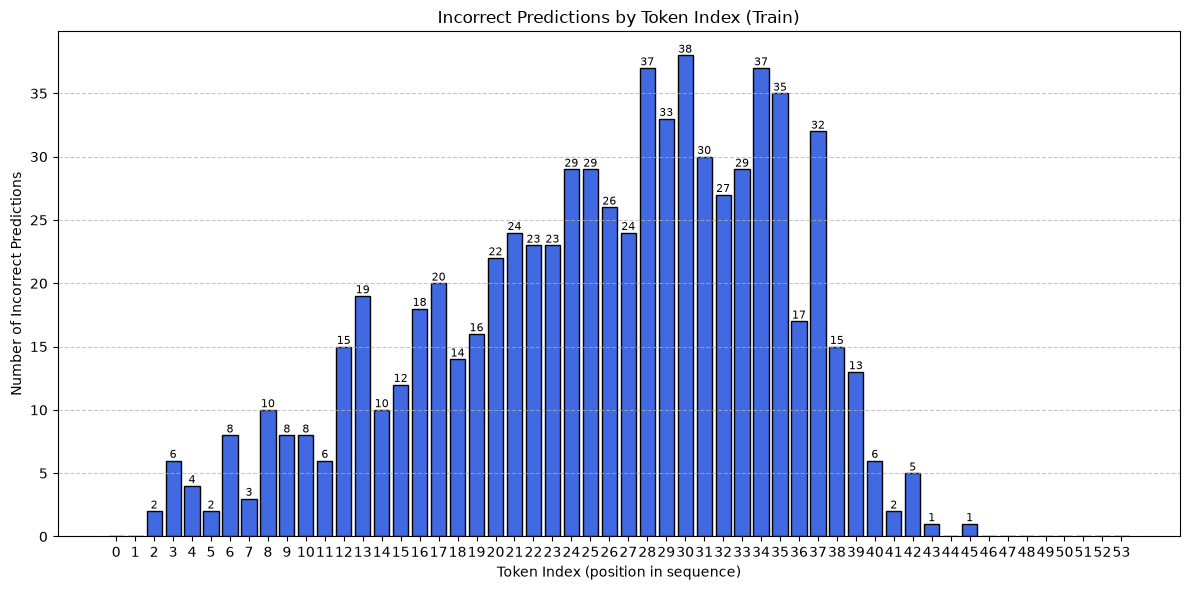

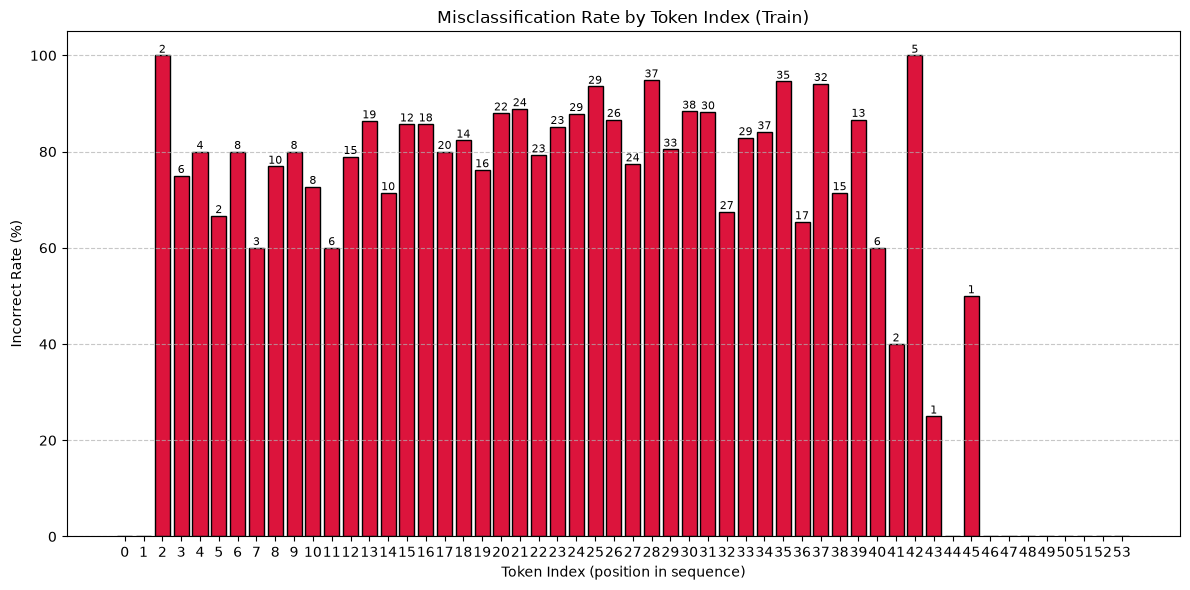

In [38]:
import random
import matplotlib.pyplot as plt

# 1. Use the correct tensor sizes to safely map sequence layout metadata
positions = list(range(len(train_incorrect)))
counts    = train_incorrect.int().tolist()

# Find indices where error counts occurred
misclassified_positions = [i for i, error_count in enumerate(counts) if error_count > 0]

if misclassified_positions:
    print(f"\nTotal sequence positions with errors: {len(misclassified_positions)}")
    print("Random Sample of Error-Prone Token Positions:")
    
    sample_size = min(20, len(misclassified_positions))
    sampled_idx = random.sample(misclassified_positions, sample_size)
    
    for idx in sampled_idx:
        print(f"Token Position Index: {idx} | Error Count: {counts[idx]}")
else:
    print("\nNo error-prone positions found in the training slice!")

# ----------------------------------------------------
# Plot 1: Raw count of incorrect predictions at each token index
# ----------------------------------------------------
plt.figure(figsize=(12, 6))
bars = plt.bar(positions, counts, edgecolor='black', color='royalblue')
for bar, c in zip(bars, counts):
    if c > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha='center', va='bottom', fontsize=8)
plt.title("Incorrect Predictions by Token Index (Train)")
plt.xlabel("Token Index (position in sequence)")
plt.ylabel("Number of Incorrect Predictions")
plt.xticks(positions)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ----------------------------------------------------
# Plot 2: Misclassification rate at each token index
# ----------------------------------------------------
percent = [100 * i / t if t > 0 else 0.0
           for i, t in zip(train_incorrect.tolist(), train_total.tolist())]
plt.figure(figsize=(12, 6))
bars = plt.bar(positions, percent, edgecolor='black', color='crimson')
for bar, c in zip(bars, counts):
    if c > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha='center', va='bottom', fontsize=8)
plt.title("Misclassification Rate by Token Index (Train)")
plt.xlabel("Token Index (position in sequence)")
plt.ylabel("Incorrect Rate (%)")
plt.xticks(positions)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Test Misclassification Graphs


Random Sample of Misclassified Test Sequences:
Word: 2 3 1 2 3 1 2 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 0 0 0 0 0 0 0 0 0 0 0 | Length: 43 | Seq Acc: 0.000 | Index: 415
Word: 3 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 25 | Seq Acc: 0.000 | Index: 1114
Word: 3 1 2 3 1 2 3 1 2 1 3 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 12 | Seq Acc: 0.000 | Index: 363
Word: 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 19 | Seq Acc: 0.000 | Index: 21
Word: 1 2 3 1 2 3 1 2 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 39 | Seq Acc: 0.000 | Index: 728
Word: 3 1 2 3 1 2 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 2 1 3 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 | Length: 40 | Seq Acc: 0.000 | Index: 771
Word: 1 3 

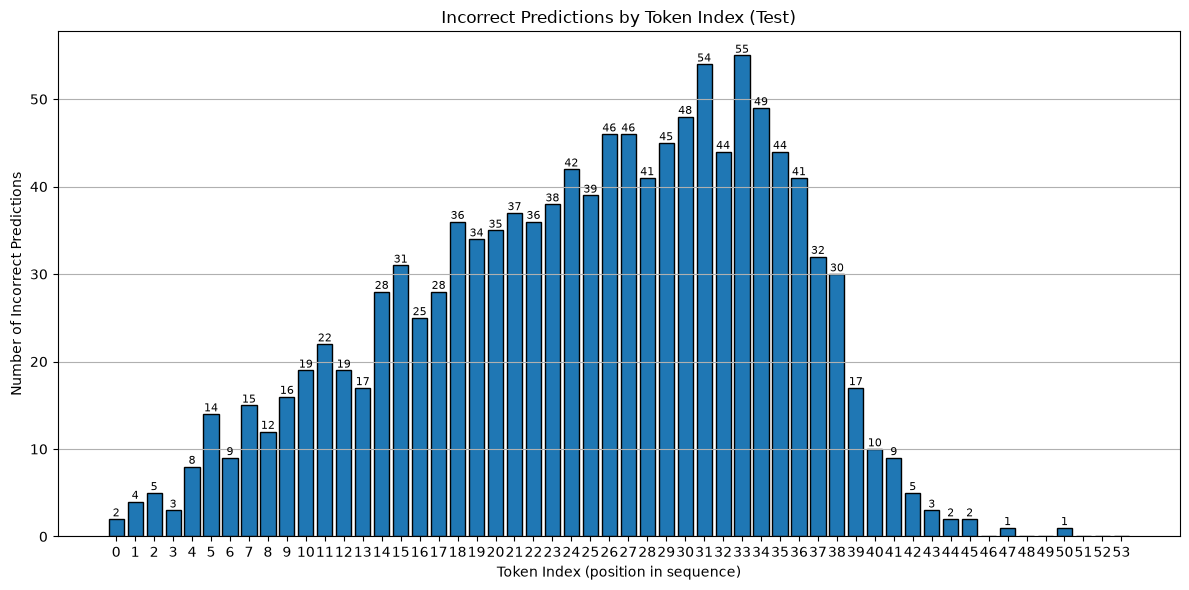

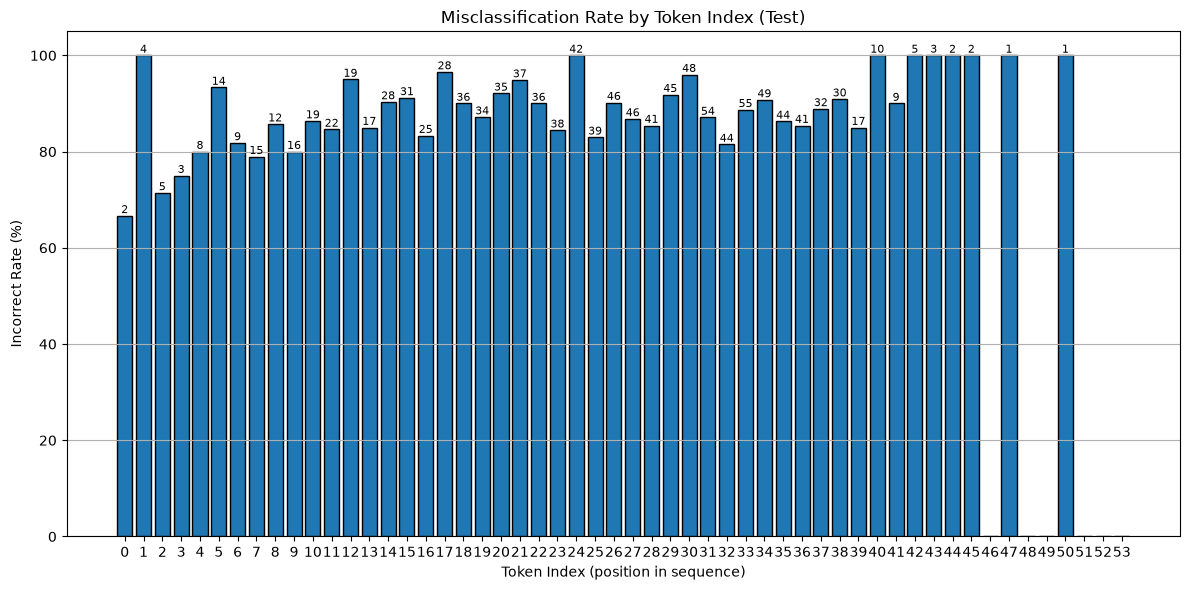

In [39]:
words = []
seq_accuracies = []
lengths = []
dataset_indices = []

total_by_length         = defaultdict(int)
misclassified_by_length = defaultdict(int)

test_tokens   = test_tokens.to(device1)
test_seq_acc  = getPredictions(model, test_tokens, test_targets, test_mask)

for i in range(len(test_tokens)):
    input_seq = test_tokens[i]
    word_str  = ' '.join([str(int(tok)) for tok in input_seq.tolist()])
    word_len  = (input_seq != 0).sum().item()   # no special token in the new format

    words.append(word_str)
    seq_accuracies.append(test_seq_acc[i].item())
    lengths.append(word_len)
    dataset_indices.append(i)

    total_by_length[word_len] += 1
    if test_seq_acc[i].item() < 1.0:
        misclassified_by_length[word_len] += 1

# Per-sequence misclassified list (used by the attention-head visualization below)
misclassified = [
    (words[i], lengths[i], seq_accuracies[i], dataset_indices[i])
    for i in range(len(words)) if seq_accuracies[i] < 1.0
]

print("\nRandom Sample of Misclassified Test Sequences:")
for word, length, acc, idx in random.sample(misclassified, min(20, len(misclassified))):
    print(f"Word: {word} | Length: {length} | Seq Acc: {acc:.3f} | Index: {idx}")

# Per-token-index error counts
test_incorrect, test_total = position_error_counts(model, test_tokens, test_targets, test_mask)
print("\nTest incorrect predictions per token index:")
print(test_incorrect.int().tolist())
print(f"Total incorrect positions: {int(test_incorrect.sum())} / {int(test_total.sum())} valid positions")

positions = list(range(len(test_incorrect)))
counts    = test_incorrect.int().tolist()

# Plot 1: Raw count of incorrect predictions at each token index
plt.figure(figsize=(12, 6))
bars = plt.bar(positions, counts, edgecolor='black')
for bar, c in zip(bars, counts):
    if c > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha='center', va='bottom', fontsize=8)
plt.title("Incorrect Predictions by Token Index (Test)")
plt.xlabel("Token Index (position in sequence)")
plt.ylabel("Number of Incorrect Predictions")
plt.xticks(positions)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Plot 2: Misclassification rate at each token index (relative to valid positions there)
percent = [100 * i / t if t > 0 else 0.0
           for i, t in zip(test_incorrect.tolist(), test_total.tolist())]
plt.figure(figsize=(12, 6))
bars = plt.bar(positions, percent, edgecolor='black')
for bar, c in zip(bars, counts):
    if c > 0:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                 str(c), ha='center', va='bottom', fontsize=8)
plt.title("Misclassification Rate by Token Index (Test)")
plt.xlabel("Token Index (position in sequence)")
plt.ylabel("Incorrect Rate (%)")
plt.xticks(positions)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Other Graphs
- check on misclassified
- attention heads of random selection of misclassified train inputs

In [40]:
print(f"total word count: {sum(total_by_length.values())}")
print(f"total misclassified count: {sum(misclassified_by_length.values())}")

total word count: 1355
total misclassified count: 1199


In [32]:
# Prints 1 graph per attention head
# x: letters (keys attended to)
# y: letters (query giving attention to x axis)

# Make sure there are at least 4 items to sample from
sample_size = min(4, len(misclassified))

# Take random sample of misclassified items
sample = random.sample(misclassified, sample_size)

misclassified_index = [index for _, _, _, index in sample]
# NOTE: the big `cache` above was computed on train_tokens, but these indices point
# into the TEST set — so run the model on each chosen test word to get its own cache.
for mis_index in misclassified_index:
    chosenWord = test_tokens[mis_index].unsqueeze(0).to(device1)  # shape (1, 22)
    _, word_cache = getLogits(model, chosenWord, getCache=True)

    # Generate labeled tokens with position

    # ex: word len 22: str_tokens = [0,...,21]
    str_tokens = [f"{i}" for i, tok in enumerate(chosenWord[0])]

    # Visualize
    n_heads = model.cfg.n_heads
    n_layers = model.cfg.n_layers
    for layer in range(n_layers):
        for head in range(n_heads):
            # this word is batch entry 0 of its own single-word cache
            attn_single_head = word_cache["pattern", layer][0, head].detach().cpu()

            imshow(
                attn_single_head,
                x=str_tokens,
                y=str_tokens,
                xaxis="Key (Attended To)",
                yaxis="Query (Paying Attention)",
                title=f"Layer {layer} Head {head} Attention Pattern (for test word {mis_index})(Positional Tokens)"
            )

In [33]:
print("Train Tokens Tensor Shape:     ", train_tokens.shape)
print("Train Incorrect Tracker Shape:", train_incorrect.shape)
print("Train Total Tracker Shape:    ", train_total.shape)

Train Tokens Tensor Shape:      torch.Size([902, 54])
Train Incorrect Tracker Shape: torch.Size([54])
Train Total Tracker Shape:     torch.Size([54])
